# Logistic Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/konstantin-schekotihin/dl_course/blob/master/AI-ML/03_logistic_regression.ipynb)


In [1]:
# Setup & configuration (skip in presentation slides)
%matplotlib inline
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ipywidgets import interact
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# Ensure helpers.py is available (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/AI-ML/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp

## 1. Qualitative Targets & Pitfalls of Linear Models

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/slide4.png" width="60%"/>
</center>

### Predicting Qualitative Variables

- Assume we want to apply linear models to predict a binary qualitative target variable $t \in \{0, 1\}$:

$$
t = 
\begin{cases}
0 & \text{for "No"} \\
1 & \text{for "Yes"}
\end{cases}
$$

- Can we simply perform an ordinary linear regression of $t$ on feature vector $\mathbf{x}$ and classify as "Yes" whenever $\hat{t} > 0.5$?
- **The Challenge**: A standard linear regression line $\mathbf{w}^\mathrm{T}\mathbf{x} + w_0$ outputs values in $(-\infty, +\infty)$, producing meaningless negative values or values exceeding $1$ when interpreted as probabilities.


### Motivating Case Study: Credit Card Default

- Dataset of $N = 10{,}000$ credit card customers.
- **Target**: Binary default status $t \in \{0, 1\}$ (`default` $\in \{\text{No}, \text{Yes}\}$).
- **Predictor Features** $\mathbf{x}$:
  - `student`: Binary indicator (Yes / No)
  - `balance`: Monthly remaining credit card balance ($)
  - `income`: Customer annual income ($)


In [2]:
# Load Default dataset (supports local cache and Colab remote stream)
data = pd.read_csv(hp.get_data_path("Default.csv"))
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])
data.head(5)


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [3]:
data.head(10)

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879
5,No,Yes,919.588530,7491.558572
6,No,No,825.513331,24905.226578
7,No,Yes,808.667504,17600.451344
8,No,No,1161.057854,37468.529288
9,No,No,0.000000,29275.268293


In [4]:
# Label encoder for class labels

le = LabelEncoder()
y = le.fit_transform(data.default)
print(le.classes_, y)

['No' 'Yes'] [0 0 0 ... 0 0 0]


In [5]:
std = StandardScaler()
X = std.fit_transform(data[['balance']])
print('Features: ', std.feature_names_in_, '\nMeans: ', std.mean_, '\nStd. deviations :', std.scale_)

Features:  ['balance'] 
Means:  [835.37488561] 
Std. deviations : [483.69079885]


### Linear Fit to Probabilities: Deficiencies
- Classification of the Default data set using *linear* and *logistic* regression

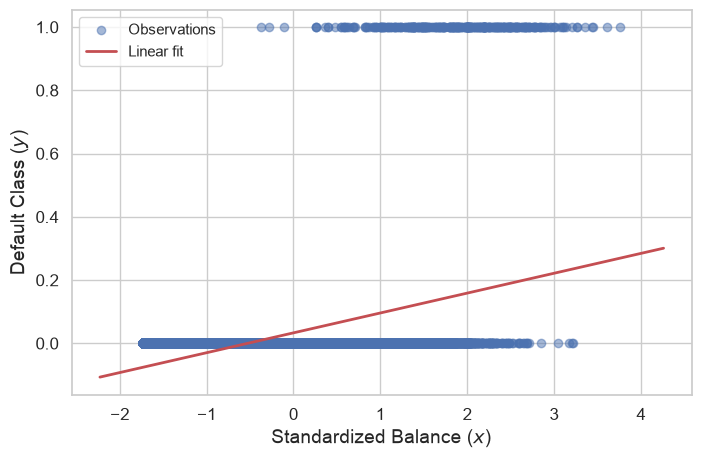

In [6]:
lin_model = LinearRegression().fit(X, y)
hp.plot_linear_fit(X, y, lin_model.predict)


### Issues with the Linear Approach

- However, linear regression might produce values that might be hard to interpret
    - The goal is not to predict a value, but to separate the examples

### The Need for Constrained Probabilities

- In classification, we need a model that directly outputs **posterior class probabilities** $p(t = 1 \mid \mathbf{x}) \in [0, 1]$.
- Linear regression yields unconstrained outputs where $y(x) < 0$ or $y(x) > 1$:

$$
y(x) = w_0 + w_1 x \quad (\text{unbounded})
$$

- **The Logistic Solution**: Map the linear combination through an **activation function** $\sigma: \mathbb{R} \to [0, 1]$:

$$
p(t = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\mathrm{T}\mathbf{x} + w_0)
$$


## 2. The Logistic Model & The Sigmoid Function
- We have to compute the probability using a function with range $[0,1]$
- There are many such functions: step function (hardlim), sigmoid, scaled hyperbolic tangent, etc. 

### The Sigmoid (Logistic) Function

- Logistic regression employs the standard **sigmoid activation function** $\sigma(a)$:

$$
\sigma(a) = \frac{1}{1 + e^{-a}} = \frac{e^a}{1 + e^a} \in (0, 1)
$$

- Passing linear argument $a = \mathbf{w}^\mathrm{T}\mathbf{x} + w_0$ into $\sigma(a)$ yields posterior class probability:

$$
p(t = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\mathrm{T}\mathbf{x} + w_0) = \frac{1}{1 + \exp(-(\mathbf{w}^\mathrm{T}\mathbf{x} + w_0))}
$$

- **Odds and Log-Odds (Logit)**: The ratio $\frac{p}{1 - p} \in (0, \infty)$ represents the **odds** (ratio of favorable to unfavorable probability), while its logarithm $\ln\left(\frac{p}{1-p}\right) \in (-\infty, +\infty)$ is the **log-odds (logit)**, which is strictly linear in parameters:

$$
\ln \left( \frac{p(t = 1 \mid \mathbf{x})}{1 - p(t = 1 \mid \mathbf{x})} \right) = \mathbf{w}^\mathrm{T}\mathbf{x} + w_0
$$

<small>📖 *Source: [Cox, D. R. (1958). The regression analysis of binary sequences. Journal of the Royal Statistical Society: Series B, 20(2), 215–238](https://doi.org/10.1111/j.2517-6161.1958.tb00292.x)*</small>


In [7]:
def sigmoid(a):
    """Standard logistic sigmoid activation function: sigma(a) = 1 / (1 + exp(-a))."""
    return 1 / (1 + np.exp(-a))

def logistic_model(w_0=-10, w_1=5):
    x_vals = np.linspace(-5, 5, 200)
    y_vals = sigmoid(w_0 + w_1 * x_vals)
    hp.plot_logistic_curve(x_vals, y_vals, w_0, w_1)

interact(logistic_model, w_0=(-10, 10, 1), w_1=(1, 10, 1));


interactive(children=(IntSlider(value=-10, description='w_0', max=10, min=-10), IntSlider(value=5, description…

## 3. Maximum Likelihood & Cross-Entropy Optimization

- Parameter weights $\mathbf{w}$ and bias $w_0$ are estimated using **Maximum Likelihood Estimation (MLE)**.
- For binary targets $t_n \in \{0, 1\}$, each observation follows a conditional Bernoulli distribution:

$$
p(t_n \mid \mathbf{x}_n, \mathbf{w}, w_0) = y_n^{t_n} (1 - y_n)^{1 - t_n}, \quad \text{where } y_n = \sigma(\mathbf{w}^\mathrm{T}\mathbf{x}_n + w_0) = p(t_n = 1 \mid \mathbf{x}_n)
$$

- Assuming independent observations conditioned on inputs, the joint **Likelihood Function** is:

$$
p(\mathbf{t} \mid \mathbf{w}, w_0) = \prod_{n=1}^{N} y_n^{t_n} (1 - y_n)^{1 - t_n}
$$


### The Cross-Entropy Error Function

- Maximizing likelihood is equivalent to minimizing the negative log-likelihood, defined as the **Cross-Entropy Error Function** $E(\mathbf{w})$:

$$
E(\mathbf{w}) = -\ln p(\mathbf{t} \mid \mathbf{w}) = -\sum_{n=1}^{N} \left\{ t_n \ln y_n + (1 - t_n) \ln (1 - y_n) \right\}
$$

- **Gradient of Cross-Entropy**: Assuming $\mathbf{x}_n = (1, x_{n1}, \dots, x_{nD})^\mathrm{T}$ includes dummy intercept $x_0 = 1$ with weight $w_0$ (so $\mathbf{w} \in \mathbb{R}^{D+1}$), the gradient vector is:

$$
\nabla E(\mathbf{w}) = \sum_{n=1}^{N} (y_n - t_n) \mathbf{x}_n = \mathbf{X}^\mathrm{T}(\mathbf{y} - \mathbf{t})
$$


### Numerical Optimization for Parameter Estimation

- A function is **positive** if  $\forall x \in \mathbb{R} \; f(x) > 0$
- Let $f(x)$ be a positive function and $x$ is its local extremum on a given interval $[a,b]$
    - E.g., for minumum this means that $\forall x'\in [a,b] \; f(x) < f(x')$
- Logarithm of any base is a monotonically increasing function, i.e., $\forall x,x' \in \mathbb{R}^+$ if $ x < x'$ then $\log(x) < \log(x')$
- Without restricting the generality, let us consider only the natural logarithms

- $(\Rightarrow)$ $\forall x'\in [a,b]$ if $f(x) < f(x')$ then $\log(f(x)) < \log(f(x'))$
- $(\Leftarrow)$ Exponential function $e^x$, the inverse of the logarithm, is also monotonically increasing, i.e., $\forall x,x' \in \mathbb{R}$ if $ x < x'$ then $e^x < e^{x'}$
    - If $x$ the minumum of $\log(f(x))$ on the interval $[a,b]$, i.e., $\forall x'\in [a,b]$ if $\log(f(x)) < \log(f(x'))$ then $e^{\log(f(x))} < e^{\log(f(x'))}$
    - Since, $e^x$ is monotonically increasing, $\log(f(x)) < \log(f(x'))$ then $e^{\log(f(x))} < e^{\log(f(x'))}$
    - Therefore, $f(x) < f(x')$ and $x$ is also the minimum of $f$

In [8]:
def likelyhood(w_0=2, w_1=1, w_2=1):
    f = lambda x: w_0 + w_1 * x + w_2 * x**2
    s = lambda x: np.log(f(x))
    v = np.vectorize(s)

    l = np.linspace(-3, 3, num=100).reshape(-1, 1)
    is_pos = not np.any(f(l) <= 0)
    hp.plot_positive_vs_log(l, f(l), v(l) if is_pos else None, is_positive=is_pos)

interact(likelyhood, w_0=(0, 10, 1), w_1=(-10, 10, 1), w_2=(1, 10, 1));


interactive(children=(IntSlider(value=2, description='w_0', max=10), IntSlider(value=1, description='w_1', max…

## 4. Empirical Case Study: Default Prediction

In [9]:
logr = sm.Logit(y, sm.add_constant(X))
print(logr.fit().summary())

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Mon, 05 Oct 2026   Pseudo R-squ.:                  0.4534
Time:                        11:49:18   Log-Likelihood:                -798.23
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                6.233e-290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0577      0.184    -32.987      0.000      -6.418      -5.698
x1             2.6598      0

- Model analysis for logistic regression is quite similar to that of linear regression
- Values of $w_i$ do *not* correspond to change in response associated with a unit increase of observation
- For instance, since p-values are very small we can assume that *default* actually depends on *balance*

## 5. Multiple Logistic Regression & Confounding

- For multiple predictors $\mathbf{x} = (x_1, \dots, x_D)^\mathrm{T}$, we extend the linear argument:

$$
\begin{aligned}
a(\mathbf{x}) &= w_0 + w_1 x_1 + \dots + w_D x_D = \mathbf{w}^\mathrm{T}\mathbf{x} + w_0 \\[6pt]
p(t = 1 \mid \mathbf{x}) &= \sigma(a(\mathbf{x})) = \frac{1}{1 + e^{-a(\mathbf{x})}}
\end{aligned}
$$

- Parameters are estimated using maximum likelihood estimation over all $D$ features simultaneously.


In [10]:
stud = OneHotEncoder().fit_transform(data.student.values.reshape(-1,1)).toarray()[:,1].reshape(-1,1)
X1=sm.add_constant(np.concatenate((X, stud), axis=1))
print(sm.Logit(y, X1).fit(method='ncg').summary())

Optimization terminated successfully.
         Current function value: 0.078584
         Iterations: 9
         Function evaluations: 9
         Gradient evaluations: 9
         Hessian evaluations: 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Mon, 05 Oct 2026   Pseudo R-squ.:                  0.4619
Time:                        11:49:18   Log-Likelihood:                -785.84
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                1.189e-293
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

- As we can see, *balance* has still the smallest p-value
- Its coefficient suggests that *balance* has a positive influence on *default*
- *x2* is a dummy variable that takes $1$ for student value "Yes" and $0$ otherwise
- The p-value indicates that the value of *default* depends on it
- However, this dependence is negative

## 6. Algorithm Selection Card: Logistic Regression

| Dimension | Assessment & Practical Guidance |
| :--- | :--- |
| **Best Suited For** | Binary and multi-class classification where calibrated class probabilities and interpretable odds ratios are required. |
| **Key Hyperparameters** | • Decision Threshold $\tau$ (default: 0.5; adjust lower to increase recall/sensitivity for high-cost false negatives).<br>• Regularization Penalty ($L_1$ Lasso, $L_2$ Ridge, or ElasticNet) with inverse strength $C$. |
| **Interpretability vs. Capacity** | **High Interpretability**: Exponentiated weights $\exp(w_j)$ directly yield the **Odds Ratio** ($e^{w_j}$ is the multiplicative change in odds per unit increase in $x_j$). |
| **Critical Pitfalls** | • **Linear Decision Boundary**: Cannot separate classes requiring complex non-linear combinations unless paired with basis functions or neural layers.<br>• **Class Imbalance**: Default threshold $\tau=0.5$ fails when positive class is rare; evaluate via Precision-Recall and ROC-AUC curves. |

> 💡 **The Bridge to Deep Learning:** Logistic regression represents a **single artificial neuron** ($y = \sigma(\mathbf{w}^\mathrm{T}\mathbf{x} + w_0)$). Stacking multiple such neurons in successive layers forms a **Multi-Layer Perceptron (Neural Network)**.
